In [65]:
from functools import reduce

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import json

In [66]:
def flatten_results(path):
    with open(path, "r") as f:
        data = json.load(f)
    
    return [item for sublist in data for item in sublist]

def mdb_read_json(dir):
    path = f"jsonbench/results/mongodb/{dir}/results.json"
    return pd.DataFrame(flatten_results(path))

def cb_read_json(dir):
    path = f"jsonbench/results/couchbase/{dir}/results.json"
    return pd.DataFrame(flatten_results(path))

In [132]:
# MongoDB

# Scale factor: 10
mdb_s10_w2 = mdb_read_json("20251105-1911")
mdb_s10_w4 = mdb_read_json("20251105-1855")
mdb_s10_w8 = mdb_read_json("20251105-1845")
mdb_s10_w16 = mdb_read_json("20251105-1835")
mdb_s10_w32 = mdb_read_json("20251105-1827")
mdb_s10_w64 = mdb_read_json("20251105-1820")
mdb_s10 = [mdb_s10_w2, mdb_s10_w4, mdb_s10_w8, mdb_s10_w16, mdb_s10_w32, mdb_s10_w64]

# Scale factor: 50
mdb_s50_w2 = mdb_read_json("20251105-1224")
mdb_s50_w4 = mdb_read_json("20251105-1230")
mdb_s50_w8 = mdb_read_json("20251105-1236")
mdb_s50_w16 = mdb_read_json("20251105-1243")
mdb_s50_w32 = mdb_read_json("20251105-1255")
mdb_s50_w64 = mdb_read_json("20251105-1312")
mdb_s50 = [mdb_s50_w2, mdb_s50_w4, mdb_s50_w8, mdb_s50_w16, mdb_s50_w32, mdb_s50_w64]

# Scale factor: 100
mdb_s100_w2 = mdb_read_json("20251106-1629")
mdb_s100_w4 = mdb_read_json("20251106-1638")
mdb_s100_w8 = mdb_read_json("20251106-1645")
mdb_s100_w16 = mdb_read_json("20251106-1653")
mdb_s100_w32 = mdb_read_json("20251106-1709")
mdb_s100_w64 = mdb_read_json("20251106-1725")
mdb_s100 = [mdb_s100_w2, mdb_s100_w4, mdb_s100_w8, mdb_s100_w16, mdb_s100_w32, mdb_s100_w64]

# Scale factor: 150
mdb_s150_w2 = mdb_read_json("20251106-2306")
mdb_s150_w4 = mdb_read_json("20251106-2317")
mdb_s150_w8 = mdb_read_json("20251106-2340")
mdb_s150_w16 = mdb_read_json("20251107-0026")
mdb_s150_w32 = mdb_read_json("20251107-0044")
mdb_s150_w64 = mdb_read_json("20251107-0106")
mdb_s150 = [mdb_s150_w2, mdb_s150_w4, mdb_s150_w8, mdb_s150_w16, mdb_s150_w32, mdb_s150_w64]

# Scale factor: 200
mdb_s200_w2 = mdb_read_json("20251105-0443")
mdb_s200_w4 = mdb_read_json("20251105-0618")
mdb_s200_w8 = mdb_read_json("20251105-0630")
mdb_s200_w16 = mdb_read_json("20251105-0749")
mdb_s200_w32 = mdb_read_json("20251105-0813")
mdb_s200_w64 = mdb_read_json("20251105-0436")
mdb_s200 = [mdb_s200_w2, mdb_s200_w4, mdb_s200_w8, mdb_s200_w16, mdb_s200_w32, mdb_s200_w64]

In [133]:
# Couchbase

# Scale factor: 10
cb_s10_w2 = cb_read_json("20251107-2237")
cb_s10_w4 = cb_read_json("20251107-2232")
cb_s10_w8 = cb_read_json("20251107-2222")
cb_s10_w16 = cb_read_json("20251107-2219")
cb_s10_w32 = cb_read_json("20251107-2208")
cb_s10_w64 = cb_read_json("20251107-2213")
cb_s10 = [cb_s10_w2, cb_s10_w4, cb_s10_w8, cb_s10_w16, cb_s10_w32, cb_s10_w64]

# Scale factor: 100
cb_s100_w2 = cb_read_json("20251107-1652")
cb_s100_w4 = cb_read_json("20251107-1659")
cb_s100_w8 = cb_read_json("20251107-1705")
cb_s100_w16 = cb_read_json("20251107-1720")
cb_s100_w32 = cb_read_json("20251107-1727")
cb_s100_w64 = cb_read_json("20251107-1742")
cb_s100 = [cb_s100_w2, cb_s100_w4, cb_s100_w8, cb_s100_w16, cb_s100_w32, cb_s100_w64]

# Scale factor: 200
cb_s200_w2 = cb_read_json("20251107-2102")
cb_s200_w4 = cb_read_json("20251107-2106")
cb_s200_w8 = cb_read_json("20251107-2117")
cb_s200_w16 = cb_read_json("20251107-2131")
cb_s200_w32 = cb_read_json("20251107-2138")
cb_s200_w64 = cb_read_json("20251107-1953")
cb_s200 = [cb_s200_w2, cb_s200_w4, cb_s200_w8, cb_s200_w16, cb_s200_w32, cb_s200_w64]

In [ ]:
s200_w2 = pd.merge(mdb_s200_w2, cb_s200_w2, how="outer", on="name", suffixes=["_mdb", "_cb"])
s200_w2.columns = ["Query", "MongoDB", "Couchbase"]
s200_w4 = pd.merge(mdb_s200_w4, cb_s200_w4, how="outer", on="name", suffixes=["_mdb", "_cb"])
s200_w4.columns = ["Query", "MongoDB", "Couchbase"]
s200_w8 = pd.merge(mdb_s200_w8, cb_s200_w8, how="outer", on="name", suffixes=["_mdb", "_cb"])
s200_w8.columns = ["Query", "MongoDB", "Couchbase"]
s200_w16 = pd.merge(mdb_s200_w16, cb_s200_w16, how="outer", on="name", suffixes=["_mdb", "_cb"])
s200_w16.columns = ["Query", "MongoDB", "Couchbase"]
s200_w32 = pd.merge(mdb_s200_w32, cb_s200_w32, how="outer", on="name", suffixes=["_mdb", "_cb"])
s200_w32.columns = ["Query", "MongoDB", "Couchbase"]
s200_w64 = pd.merge(mdb_s200_w64, cb_s200_w64, how="inner", on="name", suffixes=["_mdb", "_cb"])
s200_w64.columns = ["Query", "MongoDB", "Couchbase"]

In [139]:
s100_w2 = pd.merge(mdb_s100_w2, cb_s100_w2, how="outer", on="name", suffixes=["_mdb", "_cb"])
s100_w2.columns = ["Query", "MongoDB", "Couchbase"]
s100_w4 = pd.merge(mdb_s100_w4, cb_s100_w4, how="outer", on="name", suffixes=["_mdb", "_cb"])
s100_w4.columns = ["Query", "MongoDB", "Couchbase"]
s100_w8 = pd.merge(mdb_s100_w8, cb_s100_w8, how="outer", on="name", suffixes=["_mdb", "_cb"])
s100_w8.columns = ["Query", "MongoDB", "Couchbase"]
s100_w16 = pd.merge(mdb_s100_w16, cb_s100_w16, how="outer", on="name", suffixes=["_mdb", "_cb"])
s100_w16.columns = ["Query", "MongoDB", "Couchbase"]
s100_w32 = pd.merge(mdb_s100_w32, cb_s100_w32, how="outer", on="name", suffixes=["_mdb", "_cb"])
s100_w32.columns = ["Query", "MongoDB", "Couchbase"]
s100_w64 = pd.merge(mdb_s100_w64, cb_s100_w64, how="inner", on="name", suffixes=["_mdb", "_cb"])
s100_w64.columns = ["Query", "MongoDB", "Couchbase"]

In [75]:
colours = ['#4DB33D', '#E72731']

### Throughput vs scale factor

In [76]:
# s200_w2_throughput = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [len(mdb_s1_w2)/300, len(mdb_s10_w2)/300, len(mdb_s50_w2)/300, len(mdb_s100_w2)/300, len(mdb_s150_w2)/300, len(mdb_s200_w2)/300],
#     "Couchbase": [len(cb_s1_w2)/300, len(cb_s10_w2)/300, len(cb_s50_w2)/300, len(cb_s100_w2)/300, len(cb_s150_w2)/300, len(cb_s200_w2)/300]
# })
# s200_w2_throughput['MongoDB'] = np.log10(s200_w2_throughput['MongoDB'])
# s200_w2_throughput['Couchbase'] = np.log10(s200_w2_throughput['Couchbase'])

# s200_w4_throughput = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [len(mdb_s1_w4)/300, len(mdb_s10_w4)/300, len(mdb_s50_w4)/300, len(mdb_s100_w4)/300, len(mdb_s150_w4)/300, len(mdb_s200_w4)/300],
#     "Couchbase": [len(cb_s1_w4)/300, len(cb_s10_w4)/300, len(cb_s50_w4)/300, len(cb_s100_w4)/300, len(cb_s150_w4)/300, len(cb_s200_w4)/300]
# })
# s200_w4_throughput['MongoDB'] = np.log10(s200_w4_throughput['MongoDB'])
# s200_w4_throughput['Couchbase'] = np.log10(s200_w4_throughput['Couchbase'])

# s200_w8_throughput = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [len(mdb_s1_w8)/300, len(mdb_s10_w8)/300, len(mdb_s50_w8)/300, len(mdb_s100_w8)/300, len(mdb_s150_w8)/300, len(mdb_s200_w8)/300],
#     "Couchbase": [len(cb_s1_w8)/300, len(cb_s10_w8)/300, len(cb_s50_w8)/300, len(cb_s100_w8)/300, len(cb_s150_w8)/300, len(cb_s200_w8)/300]
# })
# s200_w8_throughput['MongoDB'] = np.log10(s200_w8_throughput['MongoDB'])
# s200_w8_throughput['Couchbase'] = np.log10(s200_w8_throughput['Couchbase'])

# s200_w16_throughput = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [len(mdb_s1_w16)/300, len(mdb_s10_w16)/300, len(mdb_s50_w16)/300, len(mdb_s100_w16)/300, len(mdb_s150_w16)/300, len(mdb_s200_w16)/300],
#     "Couchbase": [len(cb_s1_w16)/300, len(cb_s10_w16)/300, len(cb_s50_w16)/300, len(cb_s100_w16)/300, len(cb_s150_w16)/300, len(cb_s200_w16)/300]
# })
# s200_w16_throughput['MongoDB'] = np.log10(s200_w16_throughput['MongoDB'])
# s200_w16_throughput['Couchbase'] = np.log10(s200_w16_throughput['Couchbase'])

# s200_w32_throughput = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [len(mdb_s1_w32)/300, len(mdb_s10_w32)/300, len(mdb_s50_w32)/300, len(mdb_s100_w32)/300, len(mdb_s150_w32)/300, len(mdb_s200_w32)/300],
#     "Couchbase": [len(cb_s1_w32)/300, len(cb_s10_w32)/300, len(cb_s50_w32)/300, len(cb_s100_w32)/300, len(cb_s150_w32)/300, len(cb_s200_w32)/300]
# })
# s200_w32_throughput['MongoDB'] = np.log10(s200_w32_throughput['MongoDB'])
# s200_w32_throughput['Couchbase'] = np.log10(s200_w32_throughput['Couchbase'])

# s200_w64_throughput = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [len(mdb_s1_w64)/300, len(mdb_s10_w64)/300, len(mdb_s50_w64)/300, len(mdb_s100_w64)/300, len(mdb_s150_w64)/300, len(mdb_s200_w64)/300],
#     "Couchbase": [len(cb_s1_w64)/300, len(cb_s10_w64)/300, len(cb_s50_w64)/300, len(cb_s100_w64)/300, len(cb_s150_w64)/300, len(cb_s200_w64)/300]
# })
# s200_w64_throughput['MongoDB'] = np.log10(s200_w64_throughput['MongoDB'])
# s200_w64_throughput['Couchbase'] = np.log10(s200_w64_throughput['Couchbase'])

s10_throughput = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [len(mdb_s10_w2)/300, len(mdb_s100_w2)/300, len(mdb_s200_w2)/300],
    "Couchbase": [len(cb_s10_w2)/180, len(cb_s100_w2)/180, len(cb_s200_w2)/180]
})

s100_throughput = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [len(mdb_s10_w4)/300, len(mdb_s100_w4)/300, len(mdb_s200_w4)/300],
    "Couchbase": [len(cb_s10_w4)/180, len(cb_s100_w4)/180, len(cb_s200_w4)/180]
})

s200_throughput = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [len(mdb_s10_w8)/300, len(mdb_s100_w8)/300, len(mdb_s200_w8)/300],
    "Couchbase": [len(cb_s10_w8)/180, len(cb_s100_w8)/180, len(cb_s200_w8)/180]
})

s200_w16_throughput = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [len(mdb_s10_w16)/300, len(mdb_s100_w16)/300, len(mdb_s200_w16)/300],
    "Couchbase": [len(cb_s10_w16)/180, len(cb_s100_w16)/180, len(cb_s200_w16)/180]
})

s200_w32_throughput = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [len(mdb_s10_w32)/300, len(mdb_s100_w32)/300, len(mdb_s200_w32)/300],
    "Couchbase": [len(cb_s10_w32)/180, len(cb_s100_w32)/180, len(cb_s200_w32)/180]
})

s200_w64_throughput = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [len(mdb_s10_w64)/300, len(mdb_s100_w64)/300, len(mdb_s200_w64)/300],
    "Couchbase": [len(cb_s10_w64)/180, len(cb_s100_w64)/180, len(cb_s200_w64)/180]
})

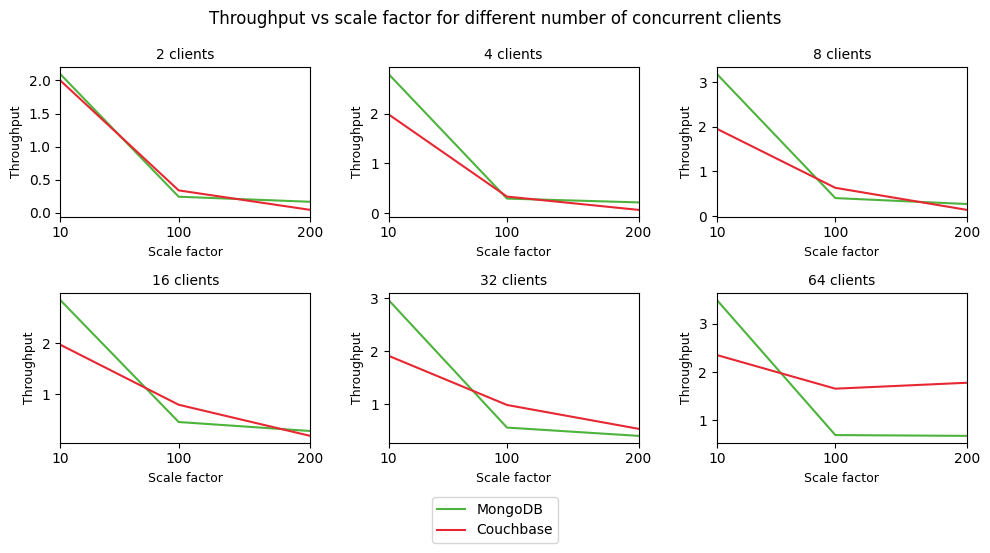

In [77]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

axs[0, 0].plot(s10_throughput['Scale Factor'], s10_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0, 0].plot(s10_throughput['Scale Factor'], s10_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[0, 0].set_title("2 clients", fontsize=10)

axs[0, 1].plot(s100_throughput['Scale Factor'], s100_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0, 1].plot(s100_throughput['Scale Factor'], s100_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[0, 1].set_title("4 clients", fontsize=10)

axs[0, 2].plot(s200_throughput['Scale Factor'], s200_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0, 2].plot(s200_throughput['Scale Factor'], s200_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[0, 2].set_title("8 clients", fontsize=10)

axs[1, 0].plot(s200_w16_throughput['Scale Factor'], s200_w16_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1, 0].plot(s200_w16_throughput['Scale Factor'], s200_w16_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[1, 0].set_title("16 clients", fontsize=10)

axs[1, 1].plot(s200_w32_throughput['Scale Factor'], s200_w32_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1, 1].plot(s200_w32_throughput['Scale Factor'], s200_w32_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[1, 1].set_title("32 clients", fontsize=10)

axs[1, 2].plot(s200_w64_throughput['Scale Factor'], s200_w64_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1, 2].plot(s200_w64_throughput['Scale Factor'], s200_w64_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[1, 2].set_title("64 clients", fontsize=10)

for ax in axs.flat:
    ax.set_xlabel("Scale factor", fontsize=9)
    ax.set_ylabel("Throughput", fontsize=9)
    ax.set_xlim(10, 200)
    ax.set_xticks([10, 100, 200])

plt.suptitle("Throughput vs scale factor for different number of concurrent clients")
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

### Throughput vs concurrency

In [78]:
s10_throughput = pd.DataFrame({
    "Concurrency": [2, 4, 8, 16, 32, 64],
    "MongoDB": [len(mdb_s10_w2)/300, len(mdb_s10_w4)/300, len(mdb_s10_w8)/300, len(mdb_s10_w16)/300, len(mdb_s10_w32)/300, len(mdb_s10_w64)/300],
    "Couchbase": [len(cb_s10_w2)/180, len(cb_s10_w4)/180, len(cb_s10_w8)/180, len(cb_s10_w16)/180, len(cb_s10_w32)/180, len(cb_s10_w64)/180]
})

s100_throughput = pd.DataFrame({
    "Concurrency": [2, 4, 8, 16, 32, 64],
    "MongoDB": [len(mdb_s100_w2)/300, len(mdb_s100_w4)/300, len(mdb_s100_w8)/300, len(mdb_s100_w16)/300, len(mdb_s100_w32)/300, len(mdb_s100_w64)/300],
    "Couchbase": [len(cb_s100_w2)/180, len(cb_s100_w4)/180, len(cb_s100_w8)/180, len(cb_s100_w16)/180, len(cb_s100_w32)/180, len(cb_s100_w64)/180]
})

s200_throughput = pd.DataFrame({
    "Concurrency": [2, 4, 8, 16, 32, 64],
    "MongoDB": [len(mdb_s200_w2)/300, len(mdb_s200_w4)/300, len(mdb_s200_w8)/300, len(mdb_s200_w16)/300, len(mdb_s200_w32)/300, len(mdb_s200_w64)/300],
    "Couchbase": [len(cb_s200_w2)/180, len(cb_s200_w4)/180, len(cb_s200_w8)/180, len(cb_s200_w16)/180, len(cb_s200_w32)/180, len(cb_s200_w64)/180]
})

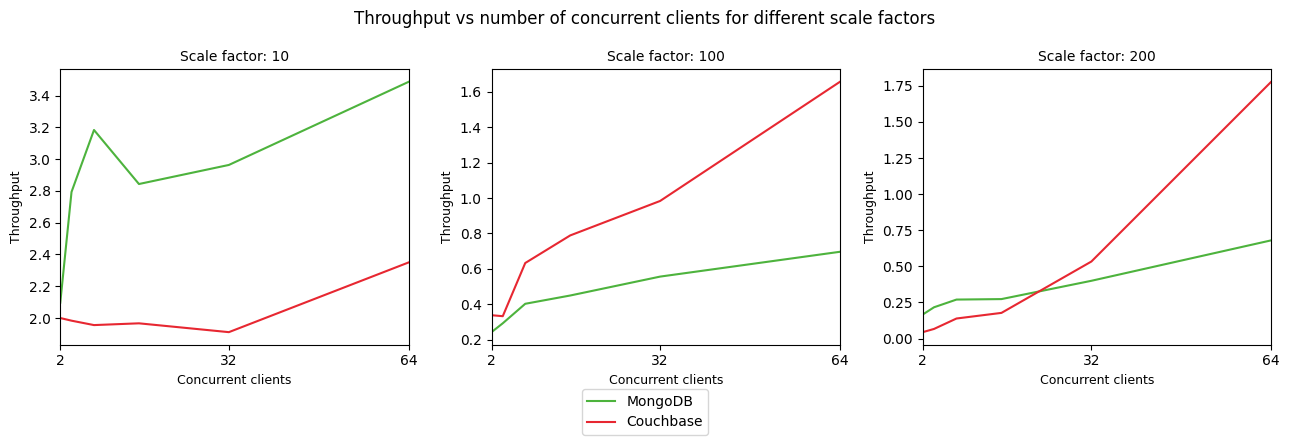

In [95]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))

axs[0].plot(s10_throughput['Concurrency'], s10_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0].plot(s10_throughput['Concurrency'], s10_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[0].set_title("Scale factor: 10", fontsize=10)

axs[1].plot(s100_throughput['Concurrency'], s100_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1].plot(s100_throughput['Concurrency'], s100_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[1].set_title("Scale factor: 100", fontsize=10)

axs[2].plot(s200_throughput['Concurrency'], s200_throughput['MongoDB'], label='MongoDB', color='#4DB33D')
axs[2].plot(s200_throughput['Concurrency'], s200_throughput['Couchbase'], label='Couchbase', color='#E72731')
axs[2].set_title("Scale factor: 200", fontsize=10)

for ax in axs.flat:
    ax.set_xlabel("Concurrent clients", fontsize=9)
    ax.set_ylabel("Throughput", fontsize=9)
    ax.set_xlim(2, 64)
    ax.set_xticks([2, 32, 64])

plt.suptitle("Throughput vs number of concurrent clients for different scale factors")
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

### Average latency vs scale factor

In [80]:
# s200_w2_latency = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [300/len(mdb_s1_w2), 300/len(mdb_s10_w2), 300/len(mdb_s50_w2), 300/len(mdb_s100_w2), 300/len(mdb_s150_w2), 300/len(mdb_s200_w2)],
#     "Couchbase": [300/len(cb_s1_w2), 300/len(cb_s10_w2), 300/len(cb_s50_w2), 300/len(cb_s100_w2), 300/len(cb_s150_w2), 300/len(cb_s200_w2)]
# })
# s200_w2_latency['MongoDB'] = np.log10(s200_w2_latency['MongoDB'])
# s200_w2_latency['Couchbase'] = np.log10(s200_w2_latency['Couchbase'])

# s200_w4_latency = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [300/len(mdb_s1_w4), 300/len(mdb_s10_w4), 300/len(mdb_s50_w4), 300/len(mdb_s100_w4), 300/len(mdb_s150_w4), 300/len(mdb_s200_w4)],
#     "Couchbase": [300/len(cb_s1_w4), 300/len(cb_s10_w4), 300/len(cb_s50_w4), 300/len(cb_s100_w4), 300/len(cb_s150_w4), 300/len(cb_s200_w4)]
# })
# s200_w4_latency['MongoDB'] = np.log10(s200_w4_latency['MongoDB'])
# s200_w4_latency['Couchbase'] = np.log10(s200_w4_latency['Couchbase'])

# s200_w8_latency = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [300/len(mdb_s1_w8), 300/len(mdb_s10_w8), 300/len(mdb_s50_w8), 300/len(mdb_s100_w8), 300/len(mdb_s150_w8), 300/len(mdb_s200_w8)],
#     "Couchbase": [300/len(cb_s1_w8), 300/len(cb_s10_w8), 300/len(cb_s50_w8), 300/len(cb_s100_w8), 300/len(cb_s150_w8), 300/len(cb_s200_w8)]
# })
# s200_w8_latency['MongoDB'] = np.log10(s200_w8_latency['MongoDB'])
# s200_w8_latency['Couchbase'] = np.log10(s200_w8_latency['Couchbase'])

# s200_w16_latency = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [300/len(mdb_s1_w16), 300/len(mdb_s10_w16), 300/len(mdb_s50_w16), 300/len(mdb_s100_w16), 300/len(mdb_s150_w16), 300/len(mdb_s200_w16)],
#     "Couchbase": [300/len(cb_s1_w16), 300/len(cb_s10_w16), 300/len(cb_s50_w16), 300/len(cb_s100_w16), 300/len(cb_s150_w16), 300/len(cb_s200_w16)]
# })
# s200_w16_latency['MongoDB'] = np.log10(s200_w16_latency['MongoDB'])
# s200_w16_latency['Couchbase'] = np.log10(s200_w16_latency['Couchbase'])

# s200_w32_latency = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [300/len(mdb_s1_w32), 300/len(mdb_s10_w32), 300/len(mdb_s50_w32), 300/len(mdb_s100_w32), 300/len(mdb_s150_w32), 300/len(mdb_s200_w32)],
#     "Couchbase": [300/len(cb_s1_w32), 300/len(cb_s10_w32), 300/len(cb_s50_w32), 300/len(cb_s100_w32), 300/len(cb_s150_w32), 300/len(cb_s200_w32)]
# })
# s200_w32_latency['MongoDB'] = np.log10(s200_w32_latency['MongoDB'])
# s200_w32_latency['Couchbase'] = np.log10(s200_w32_latency['Couchbase'])

# s200_w64_latency = pd.DataFrame({
#     "Scale Factor": [1, 10, 50, 100, 150, 200],
#     "MongoDB": [300/len(mdb_s1_w64), 300/len(mdb_s10_w64), 300/len(mdb_s50_w64), 300/len(mdb_s100_w64), 300/len(mdb_s150_w64), 300/len(mdb_s200_w64)],
#     "Couchbase": [300/len(cb_s1_w64), 300/len(cb_s10_w64), 300/len(cb_s50_w64), 300/len(cb_s100_w64), 300/len(cb_s150_w64), 300/len(cb_s200_w64)]
# })
# s200_w64_latency['MongoDB'] = np.log10(s200_w64_latency['MongoDB'])
# s200_w64_latency['Couchbase'] = np.log10(s200_w64_latency['Couchbase'])

s200_w2_latency = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [300/len(mdb_s10_w2), 300/len(mdb_s100_w2), 300/len(mdb_s200_w2)],
    "Couchbase": [180/len(cb_s10_w2), 180/len(cb_s100_w2), 180/len(cb_s200_w2)]
})

s200_w4_latency = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [300/len(mdb_s10_w4), 300/len(mdb_s100_w4), 300/len(mdb_s200_w4)],
    "Couchbase": [180/len(cb_s10_w4), 180/len(cb_s100_w4), 180/len(cb_s200_w4)]
})

s200_w8_latency = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [300/len(mdb_s10_w8), 300/len(mdb_s100_w8), 300/len(mdb_s200_w8)],
    "Couchbase": [180/len(cb_s10_w8), 180/len(cb_s100_w8), 180/len(cb_s200_w8)]
})

s200_w16_latency = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [300/len(mdb_s10_w16), 300/len(mdb_s100_w16), 300/len(mdb_s200_w16)],
    "Couchbase": [180/len(cb_s10_w16), 180/len(cb_s100_w16), 180/len(cb_s200_w16)]
})

s200_w32_latency = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [300/len(mdb_s10_w32), 300/len(mdb_s100_w32), 300/len(mdb_s200_w32)],
    "Couchbase": [180/len(cb_s10_w32), 180/len(cb_s100_w32), 180/len(cb_s200_w32)]
})

s200_w64_latency = pd.DataFrame({
    "Scale Factor": [10, 100, 200],
    "MongoDB": [300/len(mdb_s10_w64), 300/len(mdb_s100_w64), 300/len(mdb_s200_w64)],
    "Couchbase": [180/len(cb_s10_w64), 180/len(cb_s100_w64), 180/len(cb_s200_w64)]
})

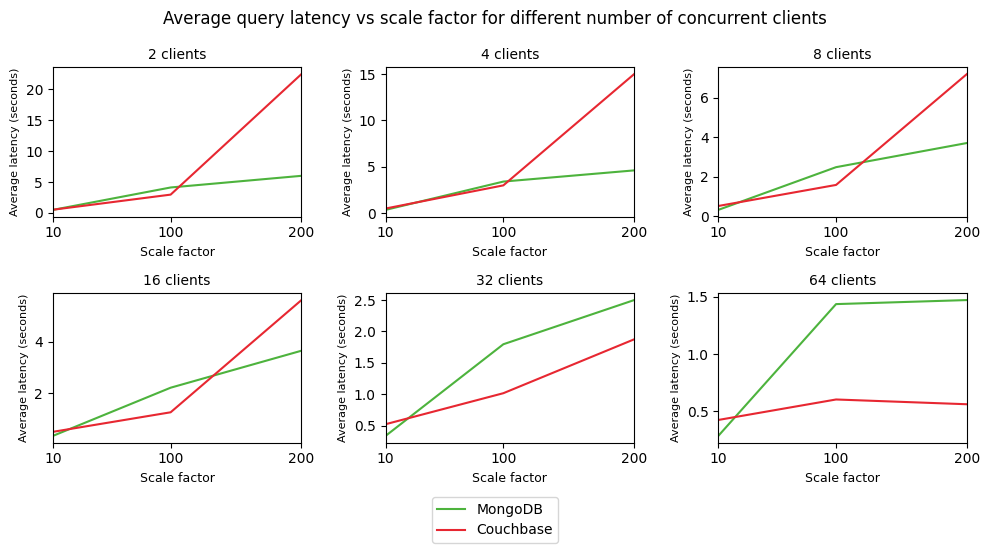

In [81]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

axs[0, 0].plot(s200_w2_latency['Scale Factor'], s200_w2_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0, 0].plot(s200_w2_latency['Scale Factor'], s200_w2_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[0, 0].set_title("2 clients", fontsize=10)

axs[0, 1].plot(s200_w4_latency['Scale Factor'], s200_w4_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0, 1].plot(s200_w4_latency['Scale Factor'], s200_w4_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[0, 1].set_title("4 clients", fontsize=10)

axs[0, 2].plot(s200_w8_latency['Scale Factor'], s200_w8_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0, 2].plot(s200_w8_latency['Scale Factor'], s200_w8_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[0, 2].set_title("8 clients", fontsize=10)

axs[1, 0].plot(s200_w16_latency['Scale Factor'], s200_w16_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1, 0].plot(s200_w16_latency['Scale Factor'], s200_w16_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[1, 0].set_title("16 clients", fontsize=10)

axs[1, 1].plot(s200_w32_latency['Scale Factor'], s200_w32_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1, 1].plot(s200_w32_latency['Scale Factor'], s200_w32_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[1, 1].set_title("32 clients", fontsize=10)

axs[1, 2].plot(s200_w64_latency['Scale Factor'], s200_w64_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1, 2].plot(s200_w64_latency['Scale Factor'], s200_w64_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[1, 2].set_title("64 clients", fontsize=10)

for ax in axs.flat:
    ax.set_xlabel("Scale factor", fontsize=9)
    ax.set_ylabel("Average latency (seconds)", fontsize=8)
    ax.set_xlim(10, 200)
    ax.set_xticks([10, 100, 200])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.suptitle("Average query latency vs scale factor for different number of concurrent clients")
plt.tight_layout()
plt.show()

### Average latency vs concurrency

In [82]:
s10_latency = pd.DataFrame({
    "Concurrency": [2, 4, 8, 16, 32, 64],
    "MongoDB": [300/len(mdb_s10_w2), 300/len(mdb_s10_w4), 300/len(mdb_s10_w8), 300/len(mdb_s10_w16), 300/len(mdb_s10_w32), 300/len(mdb_s10_w64)],
    "Couchbase": [180/len(cb_s10_w2), 180/len(cb_s10_w4), 180/len(cb_s10_w8), 180/len(cb_s10_w16), 180/len(cb_s10_w32), 180/len(cb_s10_w64)]
})

s100_latency = pd.DataFrame({
    "Concurrency": [2, 4, 8, 16, 32, 64],
    "MongoDB": [300/len(mdb_s100_w2), 300/len(mdb_s100_w4), 300/len(mdb_s100_w8), 300/len(mdb_s100_w16), 300/len(mdb_s100_w32), 300/len(mdb_s100_w64)],
    "Couchbase": [180/len(cb_s100_w2), 180/len(cb_s100_w4), 180/len(cb_s100_w8), 180/len(cb_s100_w16), 180/len(cb_s100_w32), 180/len(cb_s100_w64)]
})

s200_latency = pd.DataFrame({
    "Concurrency": [2, 4, 8, 16, 32, 64],
    "MongoDB": [300/len(mdb_s200_w2), 300/len(mdb_s200_w4), 300/len(mdb_s200_w8), 300/len(mdb_s200_w16), 300/len(mdb_s200_w32), 300/len(mdb_s200_w64)],
    "Couchbase": [180/len(cb_s200_w2), 180/len(cb_s200_w4), 180/len(cb_s200_w8), 180/len(cb_s200_w16), 180/len(cb_s200_w32), 180/len(cb_s200_w64)]
})

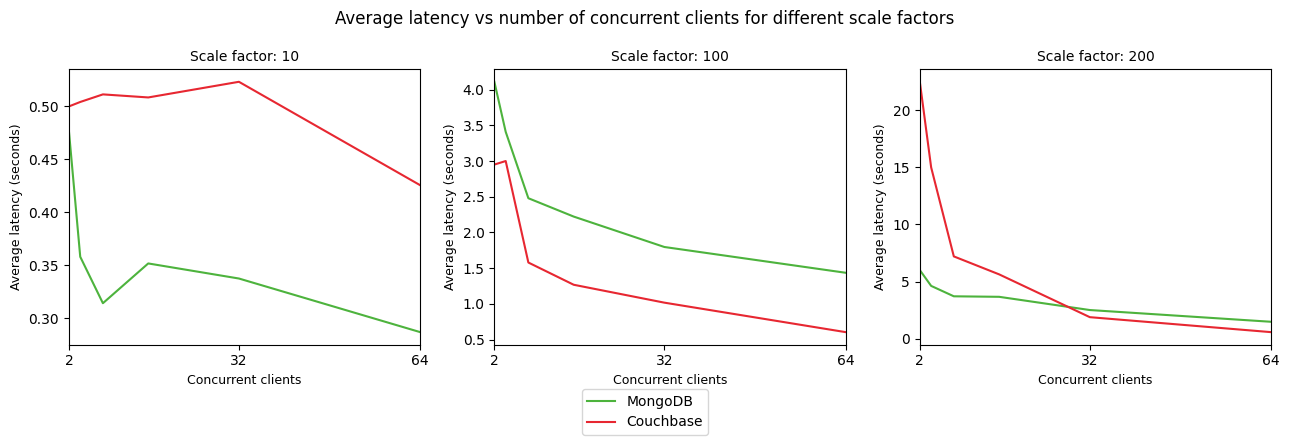

In [96]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))

axs[0].plot(s10_latency['Concurrency'], s10_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[0].plot(s10_latency['Concurrency'], s10_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[0].set_title("Scale factor: 10", fontsize=10)

axs[1].plot(s100_latency['Concurrency'], s100_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[1].plot(s100_latency['Concurrency'], s100_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[1].set_title("Scale factor: 100", fontsize=10)

axs[2].plot(s200_latency['Concurrency'], s200_latency['MongoDB'], label='MongoDB', color='#4DB33D')
axs[2].plot(s200_latency['Concurrency'], s200_latency['Couchbase'], label='Couchbase', color='#E72731')
axs[2].set_title("Scale factor: 200", fontsize=10)

for ax in axs.flat:
    ax.set_xlabel("Concurrent clients", fontsize=9)
    ax.set_ylabel("Average latency (seconds)", fontsize=9)
    ax.set_xlim(2, 64)
    ax.set_xticks([2, 32, 64])

plt.suptitle("Average latency vs number of concurrent clients for different scale factors")
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

### Average execution time vs concurrent clients

In [140]:
s100 = pd.concat([s100_w2, s100_w4, s100_w8, s100_w16, s100_w32, s100_w64], ignore_index=True)
s100

,Query,MongoDB,Couchbase
0,Query 1,0.242364,1.013605
1,Query 1,0.242364,1.159612
2,Query 1,0.242364,0.929999
3,Query 1,0.242364,0.943099
4,Query 1,0.242364,0.932702
...,...,...,...
16886,Query 6,358.970048,NaN
16887,Query 6,358.970048,NaN
16888,Query 6,358.970048,NaN
16889,Query 6,358.970048,NaN


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Query 1'),
  Text(1, 0, 'Query 2'),
  Text(2, 0, 'Query 3'),
  Text(3, 0, 'Query 4'),
  Text(4, 0, 'Query 5'),
  Text(5, 0, 'Query 6'),
  Text(6, 0, 'Query 7'),
  Text(7, 0, 'Query 8')])

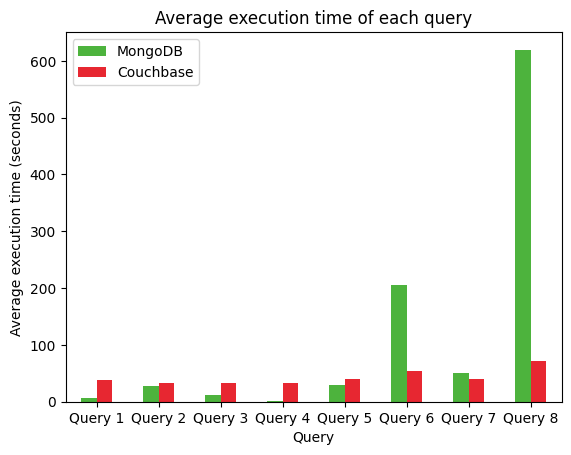

In [145]:
s100.groupby('Query').mean().plot(kind='bar', color=colours)
plt.xlabel("Query")
plt.ylabel("Average execution time (seconds)")
plt.title("Average execution time of each query")
plt.xticks(rotation=0)

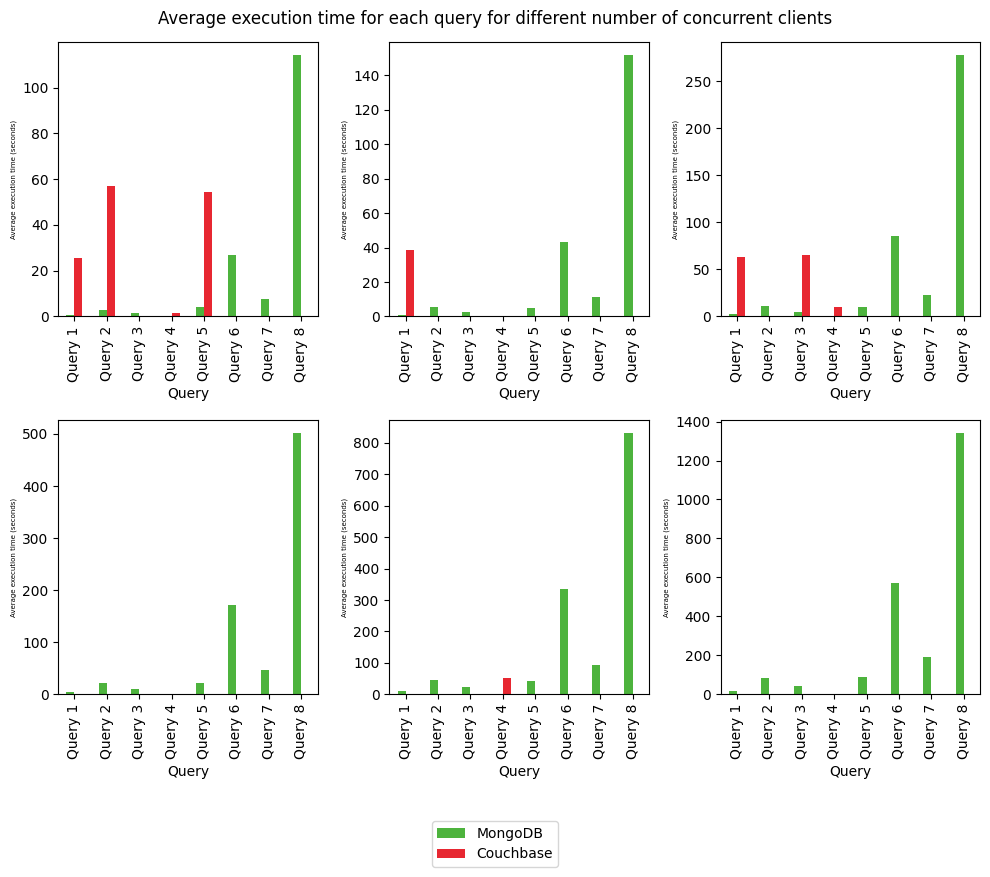

In [85]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))

s200_w2_time.plot(kind='bar', color=colours, ax=axs[0, 0], legend=False)
s200_w4_time.plot(kind='bar', color=colours, ax=axs[0, 1], legend=False)
s200_w8_time.plot(kind='bar', color=colours, ax=axs[0, 2], legend=False)
s200_w16_time.plot(kind='bar', color=colours, ax=axs[1, 0], legend=False)
s200_w32_time.plot(kind='bar', color=colours, ax=axs[1, 1], legend=False)
s200_w64_time.plot(kind='bar', color=colours, ax=axs[1, 2], legend=False)

for ax in axs.flat:
    ax.set_xlabel("Query")
    ax.set_ylabel("Average execution time (seconds)", fontsize=5)

plt.suptitle("Average execution time for each query for different number of concurrent clients")
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Average query execution time (seconds)')

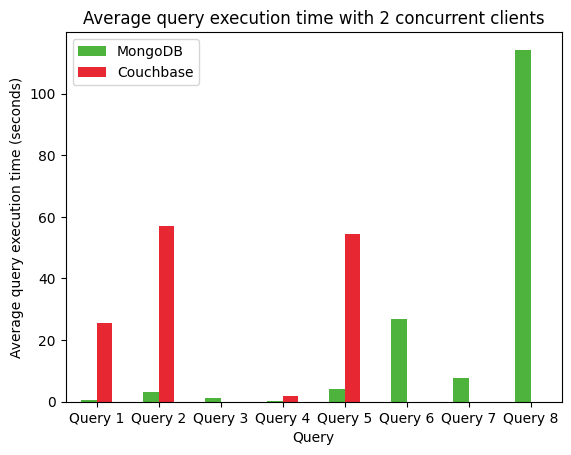

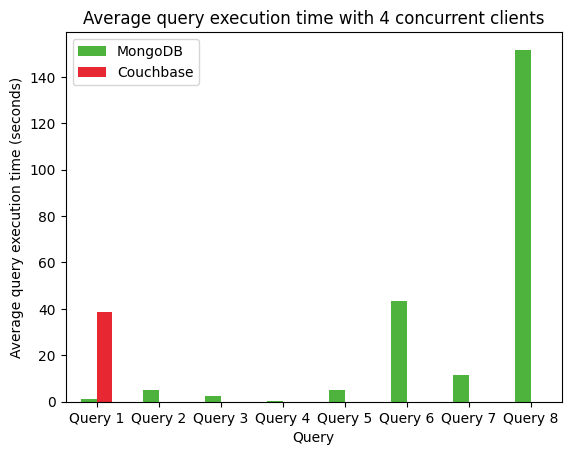

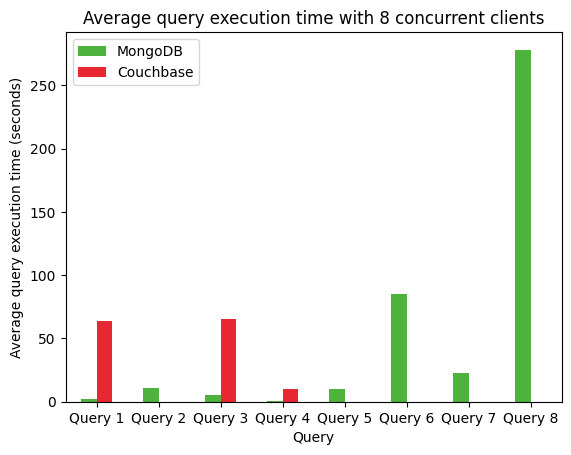

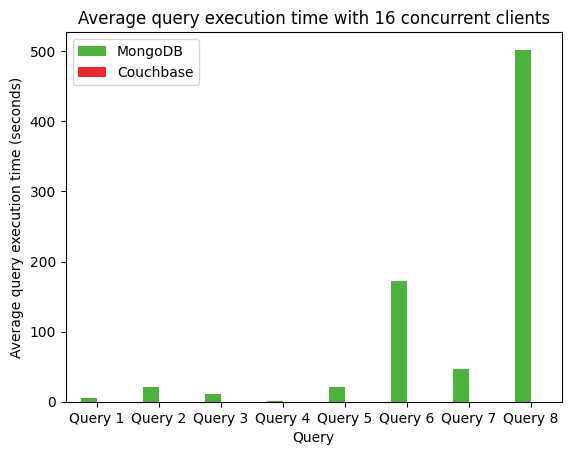

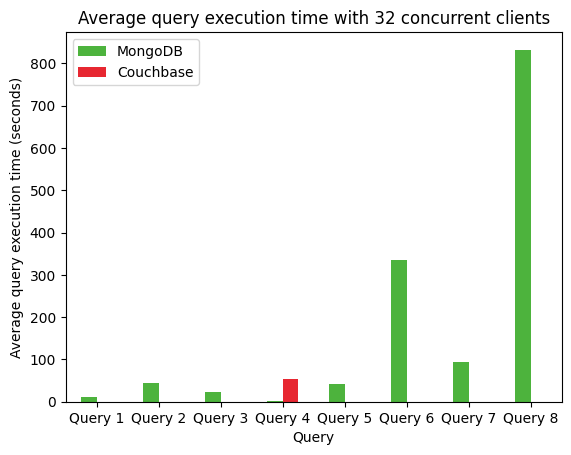

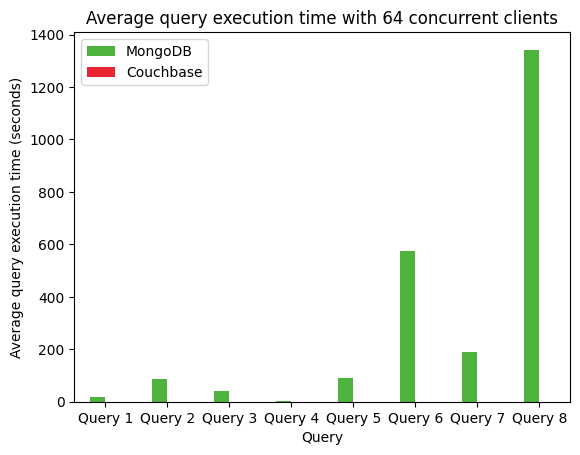

In [86]:
s200_w2_time.plot(kind='bar', color=colours)
plt.title("Average query execution time with 2 concurrent clients")
plt.xticks(rotation=0)
plt.xlabel("Query")
plt.ylabel("Average query execution time (seconds)")

s200_w4_time.plot(kind='bar', color=colours)
plt.title("Average query execution time with 4 concurrent clients")
plt.xticks(rotation=0)
plt.xlabel("Query")
plt.ylabel("Average query execution time (seconds)")

s200_w8_time.plot(kind='bar', color=colours)
plt.title("Average query execution time with 8 concurrent clients")
plt.xticks(rotation=0)
plt.xlabel("Query")
plt.ylabel("Average query execution time (seconds)")

s200_w16_time.plot(kind='bar', color=colours)
plt.title("Average query execution time with 16 concurrent clients")
plt.xticks(rotation=0)
plt.xlabel("Query")
plt.ylabel("Average query execution time (seconds)")

s200_w32_time.plot(kind='bar', color=colours)
plt.title("Average query execution time with 32 concurrent clients")
plt.xticks(rotation=0)
plt.xlabel("Query")
plt.ylabel("Average query execution time (seconds)")

s200_w64_time.plot(kind='bar', color=colours)
plt.title("Average query execution time with 64 concurrent clients")
plt.xticks(rotation=0)
plt.xlabel("Query")
plt.ylabel("Average query execution time (seconds)")

### Query execution distribution

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3)

s200_w2.plot(kind='box', ax=axs[0, 0], legend=False)
s200_w4.plot(kind='box', ax=axs[0, 1], legend=False)
s200_w8.plot(kind='box', ax=axs[0, 2], legend=False)
s200_w16.plot(kind='box', ax=axs[1, 0], legend=False)
s200_w32.plot(kind='box', ax=axs[1, 1], legend=False)
s200_w64.plot(kind='box', ax=axs[1, 2], legend=False)

for ax in axs.flat:
    ax.set_xlabel("Query")
    ax.set_ylabel("Average execution time (seconds, log10 scale)", fontsize=5)

plt.suptitle("Average execution time for each query for different number of concurrent clients")
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

In [154]:
s200_w32_latency

,Scale Factor,MongoDB,Couchbase
0,10,0.337458,0.523256
1,100,1.796407,1.016949
2,200,2.500000,1.875000
